# AND gate using Adaline 

#### Formal Definiton:

**ADALINE (Adaptive Linear Neuron)** is a single-layer neural network model developed by *Bernard Widrow and Ted Hoff*. 
Unlike the basic Perceptron, which updates weights based on the final thresholded output (0 or 1), ADALINE uses a **Linear Activation Function** to update weights based on the continuous net input before it is thresholded. 
This allows it to **minimize the Mean Squared Error (MSE)** using a process called **Gradient Descent**.

#### Task
This task involves training a mathematical model to find a decision boundary (a line) that separates the "1" case from the "0" cases.

The key difference from a Perceptron: ADALINE calculates how far it was from the right answer (the error) using a continuous value, making the learning process smoother.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.animation import FuncAnimation
from IPython.display import HTML



### 1. Dataset (AND Gate)
Inputs: [x1, x2], Targets: y
| Input $x_1$ | Input $x_2$ | Target ($y$) |
| :---: | :---: | :---: |
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | 1 |

In [2]:
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 0, 0, 1])

### 2. Setup ADALINE Parameters
Low learning rate to see movement.
Initialize weights slightly offset from zero to see the initial line.
eta - Learning rate

In [3]:
weights = np.array([0.1, 0.2])
bias = -0.3
eta = 0.05  
epochs = 30

history = []
history.append((weights.copy(), bias))


### 3. Running the Training


In [5]:
epoch_data = []

for epoch in range(epochs):
    total_epoch_error = 0
    
    for i in range(len(X)):
        # 1. Calculate Net Input (Linear Activation)
        net_input = np.dot(X[i], weights) + bias
        
        # 2. Calculate Continuous Error
        error = y[i] - net_input
        total_epoch_error += error**2 
        
        # 3. Update Weights and Bias (Widrow-Hoff Rule)
        weights += eta * error * X[i]
        bias += eta * error
        
        # 4. Save this state for history and animations
        history.append((weights.copy(), bias))

    # Calculate metrics once the pass through the dataset is complete
    mse = total_epoch_error / len(X)
    
    epoch_data.append({
        "Epoch": epoch,
        "Weights": weights.copy(),
        "Bias": f"{bias:.4f}",
        "MSE": f"{mse:.4f}"
    })

df_results = pd.DataFrame(epoch_data)
display(df_results)

,Epoch,Weights,Bias,MSE
0,0,"[0.44163911487252006, 0.45065484840771175]",-0.1701,0.0723
1,1,"[0.44459453114460223, 0.45243673338783846]",-0.1731,0.0721
2,2,"[0.44744280101092, 0.45417281044463265]",-0.1760,0.0719
3,3,"[0.45018806589233584, 0.4558640407947459]",-0.1788,0.0717
4,4,"[0.45283427609857113, 0.4575113580857822]",-0.1815,0.0716
5,5,"[0.45538520636726926, 0.45911567571905715]",-0.1841,0.0714
6,6,"[0.4578444685735331, 0.46067789170570306]",-0.1867,0.0713
7,7,"[0.4602155223520156, 0.4621988917966999]",-0.1891,0.0711
8,8,"[0.46250168416347903, 0.4636795514123978]",-0.1915,0.0710
9,9,"[0.46470613518787096, 0.4651207367440408]",-0.1938,0.0709



### 4. Setting up the "Canvas"

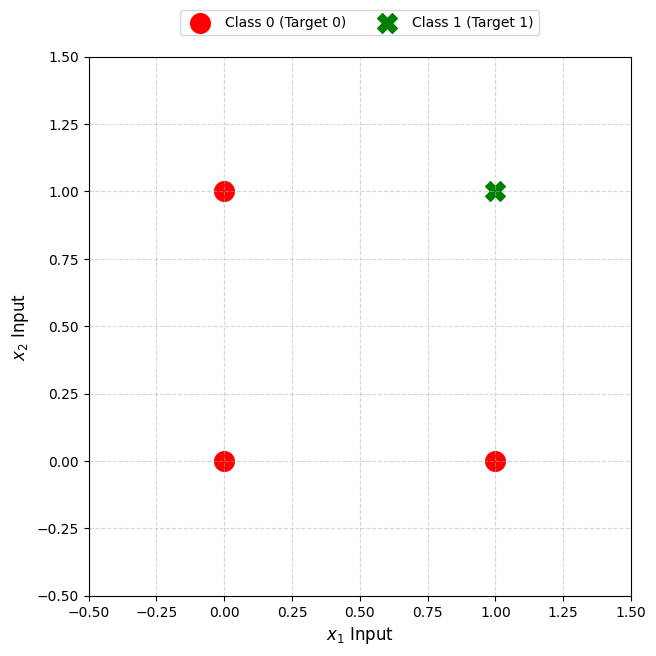

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))

# Plot the static data points once
# Mask the data: Red (Class 0) / Green (Class 1)
class0_mask = (y == 0)
class1_mask = (y == 1)

ax.scatter(X[class0_mask, 0], X[class0_mask, 1], c='red', marker='o', s=200, label='Class 0 (Target 0)')
ax.scatter(X[class1_mask, 0], X[class1_mask, 1], c='green', marker='X', s=200, label='Class 1 (Target 1)')

# Setup plot boundaries (add some padding)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('$x_1$ Input', fontsize=12)
ax.set_ylabel('$x_2$ Input', fontsize=12)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2)
ax.grid(True, linestyle='--', alpha=0.5)

# Initialize an empty line object that will be updated in the animation
line, = ax.plot([], [], 'b-', lw=3, label='Decision Boundary')

# Text object to display epoch/update info
text_step = ax.text(0.05, 0.05, '', transform=ax.transAxes)

### 5. The Animation Function

In [9]:
def animate(i):
    current_w, current_b = history[i]
    w1, w2 = current_w
    
    x_coords = np.linspace(-0.5, 1.5, 10)
    
    # Division by zero protection
    safe_w2 = w2 if abs(w2) > 1e-6 else 1e-6
    
    # Decision boundary logic
    y_coords = (0.5 - current_b - (w1 * x_coords)) / safe_w2
    line.set_data(x_coords, y_coords)
    
    if i == 0:
        text_step.set_text('Status: Initializing Weights')
    else:
        epoch_num = (i - 1) // len(X) 
        sample_num = (i - 1) % len(X)
        text_step.set_text(f'Epoch: {epoch_num} | Sample Update: {sample_num}\n'
                           f'Weights: [{w1:.3f}, {w2:.3f}] | Bias: {current_b:.3f}')
    
    return line, text_step

### 6. Generate and Display the Animation

In [10]:
anim = FuncAnimation(fig, animate, frames=len(history), 
                    interval=100, blit=True, repeat=False)

# Render
HTML(anim.to_html5_video())